<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/Distribui%C3%A7%C3%A3o_Retornos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalação

In [16]:
import Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")
Pkg.add("HypothesisTests");
Pkg.add("Distributions");

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.10/Project.toml`
  [31c24e10] + Distributions v0.25.118
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [18]:
using Caramel
using Distributions
using HypothesisTests
using Plots

# Obtenção de Retornos e Visualização

In [4]:
simbolo = "GS"   # Goldman Sachs

logr = LogReturn(simbolo, Date(2020,10,01),Date(2025,01,01)) |> DataFrame
show(logr)

1068×5 DataFrame
  Row │ ticker  date        interval  type    returns
      │ String  Date        String    String  Float64
──────┼─────────────────────────────────────────────────
    1 │ GS      2020-10-02  1d        log      0.006776
    2 │ GS      2020-10-05  1d        log      0.00946
    3 │ GS      2020-10-06  1d        log     -0.003524
    4 │ GS      2020-10-07  1d        log      0.012405
    5 │ GS      2020-10-08  1d        log      0.021284
    6 │ GS      2020-10-09  1d        log     -0.002118
    7 │ GS      2020-10-12  1d        log      0.031212
    8 │ GS      2020-10-13  1d        log     -0.015579
    9 │ GS      2020-10-14  1d        log      0.00199
   10 │ GS      2020-10-15  1d        log     -0.012529
   11 │ GS      2020-10-16  1d        log     -0.011523
  ⋮   │   ⋮         ⋮          ⋮        ⋮         ⋮
 1059 │ GS      2024-12-17  1d        log     -0.020069
 1060 │ GS      2024-12-18  1d        log     -0.043441
 1061 │ GS      2024-12-19  1d        lo

In [5]:
# Selecionamos todas as linhas do dataframe (logr) e apenas a coluna :returns

returns = logr[:, :returns];

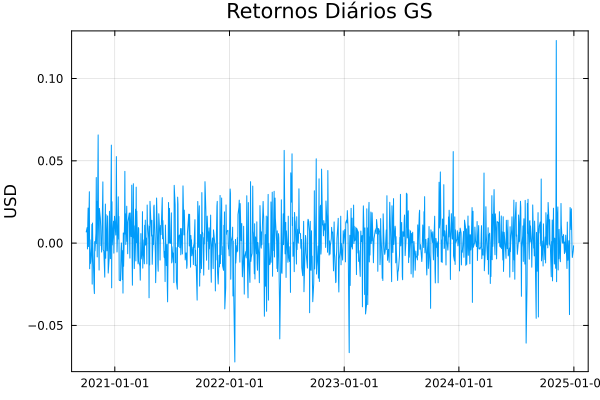

In [6]:
fig2 = plot(logr[:,:date], returns, title="Retornos Diários $(simbolo)",legend = false, ylabel="USD", framestyle = :box)

Iremos calcular de seguida (i) a média (μ) e o (ii) desvio-padrão (σ) dos retornos diários,

In [8]:
mu = mean(returns)
sigma = std(returns)
println("μ = ", mu)
println("σ = ", sigma)

μ = 0.001089132958801498
σ = 0.01662947067967996


## Histograma

Podemos visualizar o histograma dos retorns diário usando o método `histogram()` da bilioteca Plots.jl

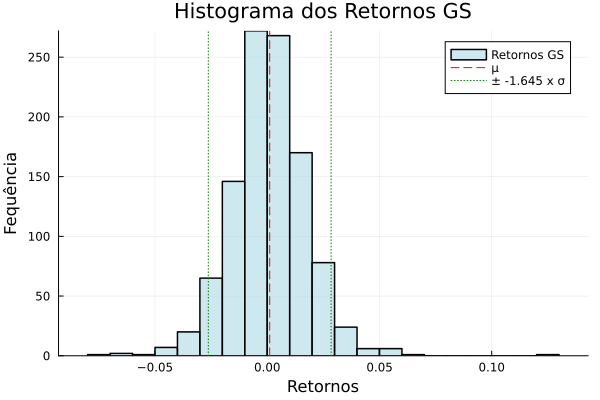

In [9]:
fig3 = histogram(returns,
          bins=30,  # Numero de barras
          color=:lightblue,
          label="Retornos $(simbolo)",
          xlabel="Retornos",
          ylabel="Fequência",
          title="Histograma dos Retornos $(simbolo)",
          grid=true,
          fillalpha=0.6,  # Transparencia das barras
          linecolor=:black,
          linewidth=1.5)

# Adicionamos linhas verticais (vline!) para a média e z * desvio-padrão

z = - 1.645   # quantil a 5% se distribuição normal(0,1)

vline!([mu], linecolor=:red, linestyle=:dash, label="μ")
vline!([mu + z * sigma, mu - z * sigma],
       linecolor=:green, linestyle=:dot, label="± $(z) x σ")

display(plot!(fig3))

# Testes de Normalidade

Em que medida uma distribuição normal representa bem a realidade empírica dos retornos observados nos últimos anos?
*   Inspeção Visual
  * $\surd$ Histograma
  * Gráficos Quantil-Quantil (não existe em Plots.jl)
*   Testes Estatísticos de Normalidade
  * Teste de Jarque-Bera
  * Teste de Shapiro-Wilk
  * Teste de Anderson-Darling (não existe em HypothesisTests.jl)





Aqui, usamos a bibioteca de testes estatísticos `HypothesisTests.jl`

Hipótese nula: os retornos têm uma distribuição normal

In [10]:
jb_test = JarqueBeraTest(returns)
println("Teste Jarque-Bera valores-p: ", pvalue(jb_test))

sw_test = ShapiroWilkTest(returns)
println("Teste Shapiro-Wilk valores-p: ", pvalue(sw_test))

Teste Jarque-Bera valores-p: 6.92913926096188e-137
Teste Shapiro-Wilk valores-p: 2.412190482995353e-13


Estes valores-p são realmente extremamente pequenos! Com o teste de Jarque-Bera e o teste de Shapiro-Wilk temos evidência muito forte para rejeitar a hipótese nula de normalidade para os retornos.
Isto é bastante comum com dados de retornos de ações, que tipicamente apresentam:
*   Caudas pesadas - eventos extremos acontecem com mais frequência do que uma distribuição normal preveria
* Leve assimetria negativa - grandes retornos negativos tendem a ser mais extremos que grandes retornos positivos

Uma vez que rejeitámos a normalidade, ajustar uma distribuição T-Student será um bom próximo passo. Como sabemos, a distribuição T-Student pode acomodar estas caudas pesadas através do seu parâmetro de graus de liberdade ($ν$). Valores mais baixos de ($ν$) indicam caudas mais pesadas.

# Optimizar o Ajustamento da Distribuição dos Retornos
- Normal
- T-Student



## Distribuição Normal

Primeiro ajustamos a distribuição Normal aos retornos observados, o que é muito simples

In [11]:
μ, σ = mean(returns), std(returns)
normal_fit = Normal(μ, σ)
println("Parâmetros: ", normal_fit)


Parâmetros: Normal{Float64}(μ=0.001089132958801498, σ=0.01662947067967996)


## Distribuição T-Student

Ajustamos agora a distribuição T-Student aos retornos obervados. Em particular, estaremos interessados em determinar o número óptimo de graus de liberdade ($ν$). A T-Student é parametrizada por: ($ν$) graus de liberdade, (μ) média, e (s) escala. De facto, para a T-Student, a relação entre o desvio-padrão (σ), parâmetro de escala (s) e graus de liberdade ($v$), é dada por,
$$\sigma = s \cdot \sqrt{v\,/\,(v-2)}$$
O Caramel faz o ajustamento à T-Student através do método de máxima verosimilhança.

In [12]:
ν_fit, μ_fit, s_fit = Caramel.fit_mle(TDist, returns)
ν_fit = Int(round(ν_fit))
println("Parâmetros: ν = ", ν_fit, ", μ = ", μ_fit, ", s = ", s_fit)

Parâmetros: ν = 6, μ = 0.0009275961495164936, s = 0.013448666925205695


## Validação do Ajustamento Óptimo da T-Student

In [13]:
𝜎_fit = s_fit * sqrt(ν_fit / (ν_fit-2.0))
println("Desvio-padrão da T-Student ajustada = ", 𝜎_fit)

println("Desvio-padrão da amostra = ", σ)

Desvio-padrão da T-Student ajustada = 0.016471185843699363
Desvio-padrão da amostra = 0.01662947067967996


Se o desvio padrão da amostra for muito diferente do da distribuição ajustada, os parâmetros estimados provavelmente estarão incorretos, e deveremos rever o processo de optimização utilizado pelo Caramel: Fminbox(LBFGS()).

# Histograma Empírico com Distribuições Ajustadas Sobrepostas

Vamos criar um gráfico (fig4) que sobrepõe ao histograma com a distrubuição empírica de retornos (fig3) as funções de densidade de probabilidade com ajustamento óptimo que determinámos para as distribuições Normal e T-Student.

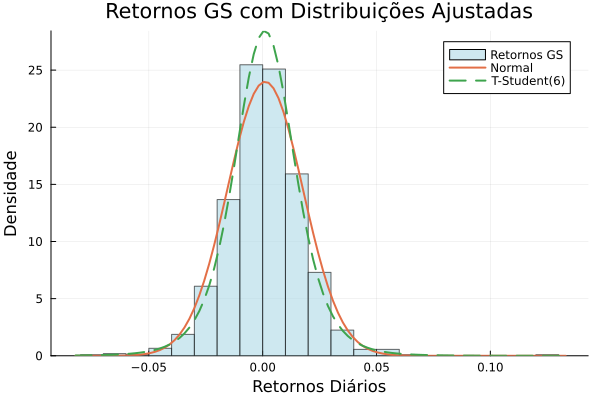

In [20]:
# T-Student
t_fit = LocationScale(μ_fit, s_fit, TDist(ν_fit))  # Usamos LocationScale para obter deslocamento/escala adequados

# Histograma com a distribuição empírica
histogram(returns, bins=30, color=:lightblue, normalize=:pdf, label="Retornos $(simbolo)", alpha=0.6)

# Sobrepomos a distribuição Normal ajustada
x_range = range(minimum(returns) - 0.01, maximum(returns) + 0.01, length=100)  # Extendemos o x_range por razões de estética...
plot!(x_range, pdf.(normal_fit, x_range), label="Normal", linewidth=2)

# Sobrepomos a distribuição T-Student óptima ajustada
fig4 = plot!(x_range, pdf.(t_fit, x_range), label="T-Student($ν_fit)", linewidth=2, linestyle=:dash)

title!("Retornos $(simbolo) com Distribuições Ajustadas")
xlabel!("Retornos Diários")
ylabel!("Densidade")